In [36]:
from google.colab import files
uploased=files.upload()

Saving govt dataset DS.csv to govt dataset DS (1).csv
Saving powerconsumption.csv to powerconsumption.csv


In [37]:
import pandas as pd
gov=pd.read_csv("/content/govt dataset DS.csv")
power=pd.read_csv("/content/powerconsumption.csv")


In [38]:
gov.head()
power.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [39]:
gov = gov.rename(columns={
    "Consumption of Electricity (in lakh units)-Total Consumption": "Total_Consumption"
})

In [40]:
gov.isnull().sum()

,0
City,0
Year,1
Consumption of Electricity (in lakh units)-Domestic purpose,1
Consumption of Electricity (in lakh units)-Commercial purpose,1
Consumption of Electricity (in lakh units)-Industry purpose,1
Consumption of Electricity (in lakh units)-Public Water Work & Street Light,1
Consumption of Electricity (in lakh units)-Others,3
Total_Consumption,0


In [43]:
import pandas as pd

# Reload power DataFrame from its intended source
power = pd.read_csv("/content/powerconsumption.csv")

power['Datetime'] = pd.to_datetime(power['Datetime'])

In [44]:
power['hour'] = power['Datetime'].dt.hour
power['day'] = power['Datetime'].dt.day
power['month'] = power['Datetime'].dt.month

In [45]:
power['Total_Power'] = (
    power['PowerConsumption_Zone1'] +
    power['PowerConsumption_Zone2'] +
    power['PowerConsumption_Zone3']
)

Model Training & Prediction

In [47]:
from sklearn.linear_model import LinearRegression

X = power[['Temperature', 'Humidity', 'hour', 'month']]
y = power['Total_Power']

model = LinearRegression()
model.fit(X, y)

power['Predicted_Load'] = model.predict(X)

print(power[['Total_Power', 'Predicted_Load']].head())

   Total_Power  Predicted_Load
0  70425.53544    42185.367538
1  69320.84387    42036.337382
2  67803.22193    41911.582695
3  65489.23209    41695.906061
4  63650.44627    41478.940184


Stress Detection

In [48]:
def detect_stress(load):
    if load < 35000:
        return "Normal"
    elif load < 42000:
        return "Warning"
    else:
        return "Critical"

power['Stress_Level'] = power['Predicted_Load'].apply(detect_stress)

print(power[['Predicted_Load', 'Stress_Level']].head())

   Predicted_Load Stress_Level
0    42185.367538     Critical
1    42036.337382     Critical
2    41911.582695      Warning
3    41695.906061      Warning
4    41478.940184      Warning


Visualization

In [50]:
import matplotlib.pyplot as plt

In [51]:
power['Predicted_Load'] = model.predict(X)

In [52]:
def stress_level(load):
    if load < 30000:
        return "Normal"
    elif load < 50000:
        return "Warning"
    else:
        return "Critical"

power['Stress_Level'] = power['Predicted_Load'].apply(stress_level)

In [53]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02)

power['Anomaly'] = iso.fit_predict(power[['Total_Power']])

In [54]:
power['Predicted_Load'] = model.predict(X)
power.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,hour,day,month,Total_Power,Predicted_Load,Stress_Level,Anomaly
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,1,1,70425.53544,42185.367538,Warning,1
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,1,1,69320.84387,42036.337382,Warning,1
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,1,1,67803.22193,41911.582695,Warning,1
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,1,1,65489.23209,41695.906061,Warning,1
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,1,1,63650.44627,41478.940184,Warning,1


In [55]:
print(power['Predicted_Load'].min())
print(power['Predicted_Load'].max())
print(power['Predicted_Load'].describe())

37254.11430122337
102255.43761529066
count     52416.000000
mean      71222.885864
std       13328.318061
min       37254.114301
25%       60074.576745
50%       72205.698663
75%       82115.634738
max      102255.437615
Name: Predicted_Load, dtype: float64


In [56]:
low = power['Predicted_Load'].quantile(0.33)
high = power['Predicted_Load'].quantile(0.66)

print("Low threshold:", low)
print("High threshold:", high)

Low threshold: 63641.15219716324
High threshold: 78799.20632920385


In [57]:
low = power['Predicted_Load'].quantile(0.5)   # 50%
high = power['Predicted_Load'].quantile(0.85) # 85%

def stress_level(load):
    if load < low:
        return "Normal"
    elif load < high:
        return "Warning"
    else:
        return "Critical"

power['Stress_Level'] = power['Predicted_Load'].apply(stress_level)

In [58]:
power['Stress_Level'].value_counts()

,count
Stress_Level,
Normal,26208
Warning,18345
Critical,7863


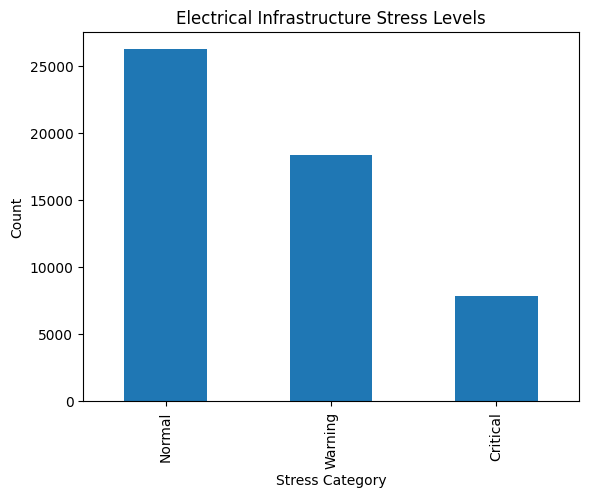

In [59]:
import matplotlib.pyplot as plt

power['Stress_Level'].value_counts().plot(kind='bar')

plt.title("Electrical Infrastructure Stress Levels")
plt.xlabel("Stress Category")
plt.ylabel("Count")

plt.show()

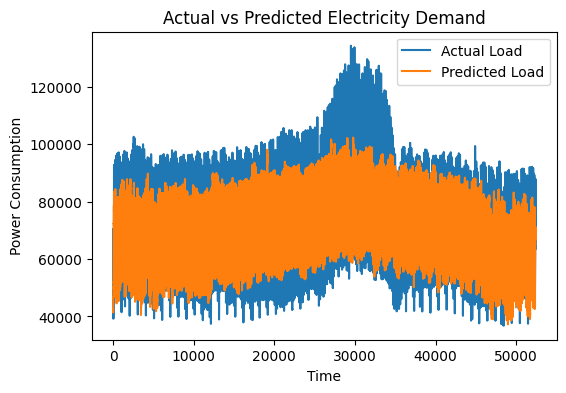

In [60]:
plt.figure(figsize=(6,4))

plt.plot(power['Total_Power'], label="Actual Load")
plt.plot(power['Predicted_Load'], label="Predicted Load")

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Time")
plt.ylabel("Power Consumption")

plt.legend()
plt.show()

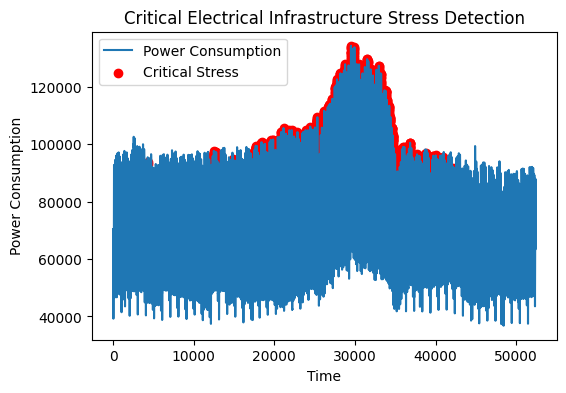

In [61]:
critical_points = power[power['Stress_Level'] == "Critical"]

plt.figure(figsize=(6,4))

plt.plot(power['Total_Power'], label="Power Consumption")
plt.scatter(critical_points.index,
            critical_points['Total_Power'],
            color='red',
            label="Critical Stress")

plt.title("Critical Electrical Infrastructure Stress Detection")
plt.xlabel("Time")
plt.ylabel("Power Consumption")

plt.legend()
plt.show()

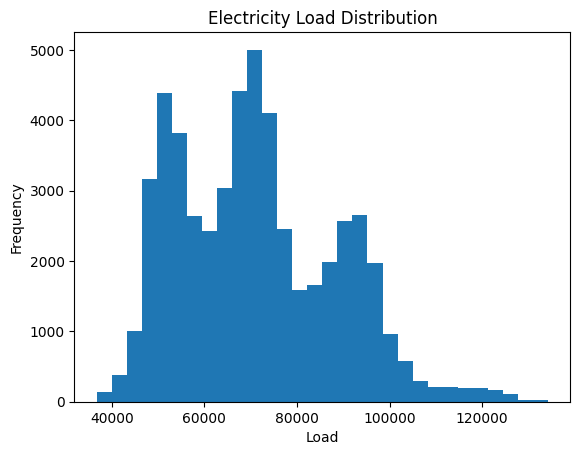

In [62]:
plt.hist(power['Total_Power'], bins=30)
plt.title("Electricity Load Distribution")
plt.xlabel("Load")
plt.ylabel("Frequency")
plt.show()

In [63]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Sample electricity load data
data = {
    'Time': pd.date_range(start='2026-03-17 00:00', periods=10, freq='H'),
    'Electricity_Load': [120, 130, 125, 140, 150, 160, 155, 145, 135, 125]
}

# Create DataFrame
df = pd.DataFrame(data)

# -------------------------------
# Step 1: Define function to classify stress level
def get_stress(load):
    if load > 150:
        return 'Critical'
    elif load > 130:
        return 'Warning'
    else:
        return 'Normal'

# Step 2: Apply function to data
df['Stress_Level'] = df['Electricity_Load'].apply(get_stress)

# Print DataFrame to see results
print(df)


                 Time  Electricity_Load Stress_Level
0 2026-03-17 00:00:00               120       Normal
1 2026-03-17 01:00:00               130       Normal
2 2026-03-17 02:00:00               125       Normal
3 2026-03-17 03:00:00               140      Warning
4 2026-03-17 04:00:00               150      Warning
5 2026-03-17 05:00:00               160     Critical
6 2026-03-17 06:00:00               155     Critical
7 2026-03-17 07:00:00               145      Warning
8 2026-03-17 08:00:00               135      Warning
9 2026-03-17 09:00:00               125       Normal


/tmp/ipykernel_508/2234542752.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Time': pd.date_range(start='2026-03-17 00:00', periods=10, freq='H'),


In [64]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load the power consumption data
power = pd.read_csv("/content/powerconsumption.csv")

# Convert 'Datetime' to datetime objects and extract features
power['Datetime'] = pd.to_datetime(power['Datetime'])
power['hour'] = power['Datetime'].dt.hour
power['day'] = power['Datetime'].dt.day # Although not used in X, good to include if relevant elsewhere
power['month'] = power['Datetime'].dt.month

# Calculate Total_Power
power['Total_Power'] = (
    power['PowerConsumption_Zone1'] +
    power['PowerConsumption_Zone2'] +
    power['PowerConsumption_Zone3']
)

# Input features
X = power[['Temperature', 'Humidity', 'hour', 'month']]

# Target variable
y = power['Total_Power']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict electricity load
power['Predicted_Load'] = model.predict(X)

# Show output
print(power[['Total_Power', 'Predicted_Load']].head())

   Total_Power  Predicted_Load
0  70425.53544    42185.367538
1  69320.84387    42036.337382
2  67803.22193    41911.582695
3  65489.23209    41695.906061
4  63650.44627    41478.940184
